# Graph Isomorphism Experiment

This notebook uses the SDK local application APIs to load MUTAG graph data, convert GBS samples into event and orbit features, and train a linear graph classifier.

## 1. Initialize the environment

In [1]:
import numpy as np

from jiuzhang.local.applications import (
    draw_graph,
    event_feature_vector,
    event_feature_vector_from_samples,
    load_graph_samples,
    load_mutag_graphs,
    orbit_feature_vector_from_samples,
    sample_to_event,
    sample_to_orbit,
    train_linear_graph_classifier,
)

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Sarasa UI SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 2. Load example graphs and sample data

In [2]:
graphs = load_mutag_graphs()
sample_sets = load_graph_samples(['samples0.npy', 'samples1.npy', 'samples2.npy', 'samples3.npy'])

print('Graph count:', len(graphs))
print('First graph shape:', graphs[0].shape)
print('First sample:', sample_sets[0][0].tolist())

Graph count: 4
First graph shape: (17, 17)
First sample: [0, 0, 0, 1, 0, 0, 0, 0, 0, 3, 2, 0, 0, 0, 0, 0, 0]


## 3. Inspect graph structures

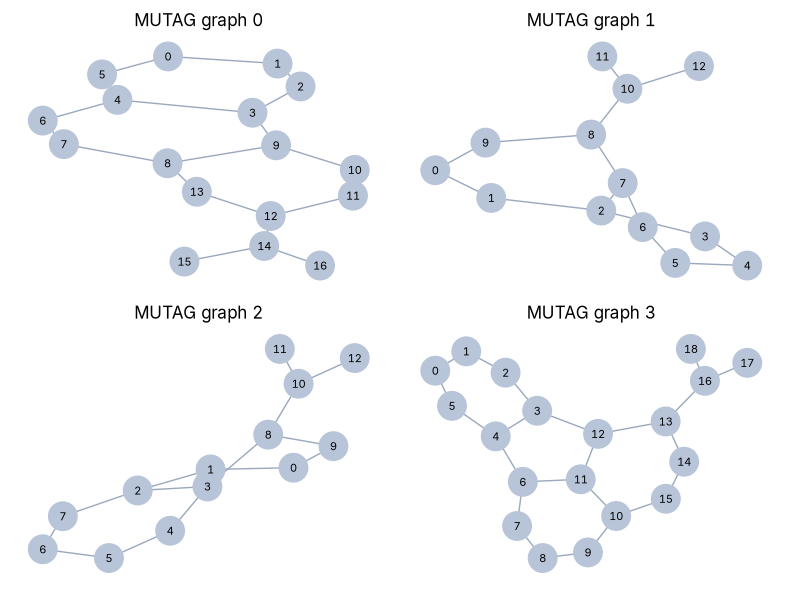

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for index, ax in enumerate(axes.ravel()):
    draw_graph(graphs[index], title=f'MUTAG graph {index}', ax=ax)
plt.tight_layout()
plt.show()

## 4. Convert samples into events and orbits

`sample_to_orbit` describes the occupation pattern as an orbit. `sample_to_event` maps a sample to an event index under the selected maximum count.

In [4]:
example_sample = sample_sets[0][0]
print('Orbit:', sample_to_orbit(example_sample))
print('Event:', sample_to_event(example_sample, max_count=3))

Orbit: [3, 2, 1]
Event: 6


## 5. Build event features

In [5]:
EVENTS = [8, 10]
MAX_COUNT = 2
features = np.array([
    event_feature_vector_from_samples(samples, EVENTS, MAX_COUNT)
    for samples in sample_sets
])
labels = np.array([1, 0, 0, 1])

print(features)

[[0.08065 0.0349 ]
 [0.06375 0.02195]
 [0.0635  0.02435]
 [0.08895 0.03945]]


## 6. Build and visualize orbit features

In [6]:
orbit_features = orbit_feature_vector_from_samples(
    sample_sets[0],
    [[1, 1], [2], [1, 1, 1, 1], [2, 1, 1]],
)
direct_features = event_feature_vector(graphs[0], [2, 4], MAX_COUNT, samples=200, mean_photon_count=5.5)

print('Orbit features:', orbit_features)
print('Direct graph features:', direct_features)

Orbit features: [0.2034  0.      0.14085 0.05215]
Direct graph features: [0.22223353 0.13113815]


## 7. Train and visualize the linear classifier

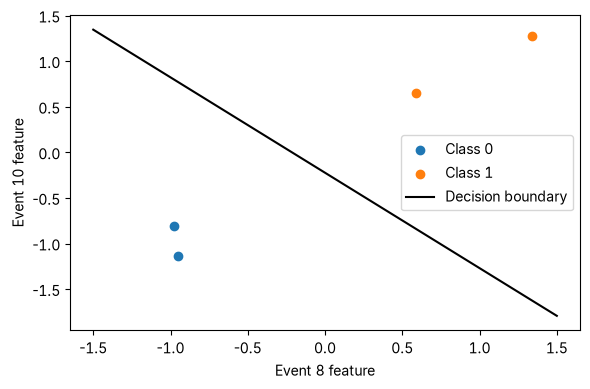

In [7]:
classification = train_linear_graph_classifier(features, labels)

plt.figure(figsize=(6, 4))
for class_id in sorted(set(classification.labels.tolist())):
    mask = classification.labels == class_id
    plt.scatter(
        classification.scaled_features[mask, 0],
        classification.scaled_features[mask, 1],
        label=f'Class {class_id}',
    )
plt.plot(classification.line_x, classification.line_y, color='black', label='Decision boundary')
plt.xlabel('Event 8 feature')
plt.ylabel('Event 10 feature')
plt.legend()
plt.tight_layout()
plt.show()